Descripción del proyecto: Analizaremos análisis en los datos de una empresa de venta de entradas de eventos. Los princiaples KPIS que analizaremos son:Usuarios en ciertos peridod de tiempo,duración de la sesión, sticky factor, LTV, revenue y ROMI dando con esto una recomendación al equipo de marketing sobre cuánto dinero invertir y en dónde.

#Importar librerías 

In [1]:
import pandas as pd

#Cargar datasets y revisar el tipo de datos que tienen mis columnas

In [2]:
visits=pd.read_csv('/datasets/visits_log_us.csv')

print(visits.info())

orders=pd.read_csv('/datasets/orders_log_us.csv')
print(orders.info())

costs=pd.read_csv('/datasets/costs_us.csv')
print(costs.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     -------------- 

#Convertir los nombres de las columnas de los datasets visits y orders a minúsculas y reemplazar los espacios por guión bajo

In [3]:
visits.columns=visits.columns.str.lower()
visits.columns = visits.columns.str.replace(' ', '_')

orders.columns=orders.columns.str.lower()
orders.columns = orders.columns.str.replace(' ', '_')

print(visits.columns)
print(orders.columns)

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')
Index(['buy_ts', 'revenue', 'uid'], dtype='object')


#Convertir las columnas de fecha al formato datetime para poder trabajar con ellas

In [4]:
visits['end_ts']=pd.to_datetime(visits['end_ts'])
visits['start_ts']=pd.to_datetime(visits['start_ts'])

orders['buy_ts']=pd.to_datetime(orders['buy_ts'])

costs['dt']=pd.to_datetime(costs['dt'])

print(visits.info())
print(orders.info())
print(costs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entri

#Crear una nueva columna para estimar la duración de la sesión

In [5]:
visits['session_duration']=visits['end_ts'] - visits['start_ts']
print(visits.head())


    device              end_ts  source_id            start_ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   

                    uid session_duration  
0  16879256277535980062  0 days 00:18:00  
1    104060357244891740  0 days 00:28:00  
2   7459035603376831527  0 days 00:00:00  
3  16174680259334210214  0 days 00:24:00  
4   9969694820036681168  0 days 00:00:00  


#Revisamos que no haya valores duplicados

In [6]:
print(visits.isna().sum())
print(orders.isna().sum())
print(costs.isna().sum())

device              0
end_ts              0
source_id           0
start_ts            0
uid                 0
session_duration    0
dtype: int64
buy_ts     0
revenue    0
uid        0
dtype: int64
source_id    0
dt           0
costs        0
dtype: int64


#Empezaremos a calcular el DAU,WAU,MAU para conocer el número de usuarios activos en el dataset visits

In [7]:
visits['session_year']=visits['start_ts'].dt.isocalendar().year
visits['session_month']=visits['start_ts'].dt.month
visits['session_week']=visits['start_ts'].dt.isocalendar().week
visits['session_date']=visits['start_ts'].dt.date

print(visits.head())




    device              end_ts  source_id            start_ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   

                    uid session_duration  session_year  session_month  \
0  16879256277535980062  0 days 00:18:00          2017             12   
1    104060357244891740  0 days 00:28:00          2018              2   
2   7459035603376831527  0 days 00:00:00          2017              7   
3  16174680259334210214  0 days 00:24:00          2018              5   
4   9969694820036681168  0 days 00:00:00          2017             12   

   session_week session_date  
0            51   2017-12-20  
1             8   2018-02-19  
2            26   2017-07-01  
3            20   2018-05-20  
4            52

#Vamos a agrupar para tener las métricas con usuarios únicos

In [8]:
dau_total=visits.groupby('session_date').agg({'uid':'nunique'}).mean()
wau_total=visits.groupby(['session_year','session_week']).agg({'uid':'nunique'}).mean()
mau_total=visits.groupby(['session_year','session_month']).agg({'uid':'nunique'}).mean()

print(dau_total)
print(wau_total)
print(mau_total)


uid    907.991758
dtype: float64
uid    5716.245283
dtype: float64
uid    23228.416667
dtype: float64


#Vamos a calcular el sticky factor: Qué tan seguido regresan los usuarios

In [9]:

sticky_wau = (dau_total / wau_total) * 100
sticky_mau = (dau_total / mau_total) * 100
print(f"Sticky WAU: {sticky_wau}")
print(f"Sticky WAU: {sticky_mau}")


Sticky WAU: uid    15.884409
dtype: float64
Sticky WAU: uid    3.90897
dtype: float64


#Este número es bajo. Se tienen usuarios de una sola vez que entran 1 vez al mes,pero no regresan diario. No se están reteniendo clientes.

#Continuamos buscando cuántas sesiones hay por día

In [10]:
visits_per_user=visits.groupby(['session_year','session_month']).agg({'uid':['count','nunique']})

In [11]:
visits_per_user.columns=['n_visits','n_users']
visits_per_user['session_per_user']=(visits_per_user['n_visits'] / visits_per_user['n_users'])
print(visits_per_user)


                            n_visits  n_users  session_per_user
session_year session_month                                     
2017         6                 16505    13259          1.244815
             7                 17828    14183          1.256998
             8                 14355    11631          1.234202
             9                 23907    18975          1.259921
             10                37903    29692          1.276539
             11                43969    32797          1.340641
             12                41983    31557          1.330386
2018         1                 36939    28716          1.286356
             2                 37182    28749          1.293332
             3                 35679    27473          1.298693
             4                 26515    21008          1.262138
             5                 26635    20701          1.286653


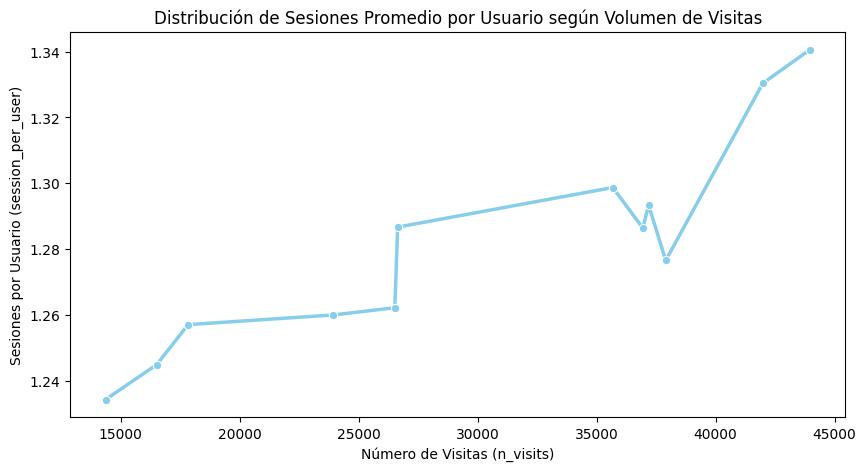

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=visits_per_user, 
    x='n_visits', 
    y='session_per_user', 
    marker='o',          
    color='#1f77b4',     
    linewidth=2.5
)
plt.title('Distribución de Sesiones Promedio por Usuario según Volumen de Visitas')
plt.xlabel('Número de Visitas (n_visits)')
plt.ylabel('Sesiones por Usuario (session_per_user)')
plt.show()

#La plataforma experimenta una fuerte estacionalidad en los meses de noviembre y diciembre, duplicando el volumen de usuarios y aumentando ligeramente la frecuencia de visitas. Sin embargo, a nivel general, el producto tiene un problema de retención y hábito: un usuario promedio apenas genera ~1.27 sesiones por mes, lo que se alinea con el bajo Sticky MAU (3.9%) que calculamos previamente.

#Calculamos la distribución o duración de cada sesión promedio

In [15]:
print(visits['session_duration'].dt.total_seconds().mean())
print(visits['session_duration'].dt.total_seconds().median())
print(visits['session_duration'].dt.total_seconds().mode())


643.0256872565387
300.0
0    60.0
dtype: float64


No handles with labels found to put in legend.


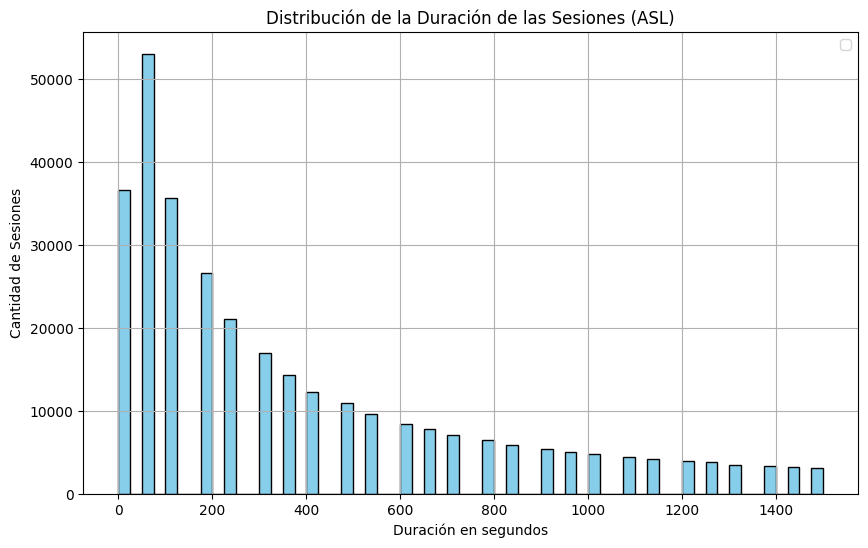

In [16]:
import matplotlib.pyplot as plt
#Convertimos la duración a segundos 
session_seconds = visits['session_duration'].dt.total_seconds()

# Creamos el histograma enfocado en los primeros 25 minutos (1500 segundos)
plt.figure(figsize=(10, 6))
session_seconds.hist(bins=60, range=(0, 1500), color='skyblue', edgecolor='black')
plt.title('Distribución de la Duración de las Sesiones (ASL)')
plt.xlabel('Duración en segundos')
plt.ylabel('Cantidad de Sesiones')
plt.legend()
plt.show()


#Acabamos de calcular el ASL es de 60 segundos (1 min).Los usuarios interactúan de manera rápida en la app.
La mediana de 5 minutos refuerza que la mayor parte del tráfico no realiza navegaciones profundas.
Nos quedamos con esta métrica debido a que el promedio de 10.7 min está sesgado por valores atípicos.
El gráfico confirma visualmente el comportamiento de los usuarios: la gran mayoría de las sesiones se concentran fuertemente entre los 0 y los 200 segundos (alrededor de la moda de 1 minuto)

In [18]:
#Continuamos analizando el dataset de ventas y empezaremos a grupar la tabla visit para encontrar con la primera fecha de su sesión

first_visit_time=visits.groupby('uid')['start_ts'].min().reset_index()
print(first_visit_time.head())

               uid            start_ts
0   11863502262781 2018-03-01 17:27:00
1   49537067089222 2018-02-06 15:55:00
2  297729379853735 2017-06-07 18:47:00
3  313578113262317 2017-09-18 22:49:00
4  325320750514679 2017-09-30 14:29:00


In [19]:
#Ahora vamos a encontrar la fecha del primer pedido de la tabla orders aplicando el mismo criterio de la anterior agrupación

first_order_time=orders.groupby('uid')['buy_ts'].min().reset_index()
print(first_order_time.head())


                uid              buy_ts
0   313578113262317 2018-01-03 21:51:00
1  1575281904278712 2017-06-03 10:13:00
2  2429014661409475 2017-10-11 18:33:00
3  2464366381792757 2018-01-28 15:54:00
4  2551852515556206 2017-11-24 10:14:00


In [20]:
#Vamos a unir las variables creadas en una sola tabla por uid

conversion= pd.merge(first_visit_time, first_order_time, on='uid', how='inner')
print(conversion.head())

                uid            start_ts              buy_ts
0   313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00
1  1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00
2  2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00
3  2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00
4  2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00


In [21]:

#Vamos a restar la fecha de compra menos la fecha de la primera visita para saber cuánto tiempo tardaron en comprar

conversion['days_to_convert'] = (conversion['buy_ts'] - conversion['start_ts']).dt.days

print(conversion.head())


                uid            start_ts              buy_ts  days_to_convert
0   313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00              106
1  1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00                0
2  2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00                0
3  2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00                0
4  2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00                0


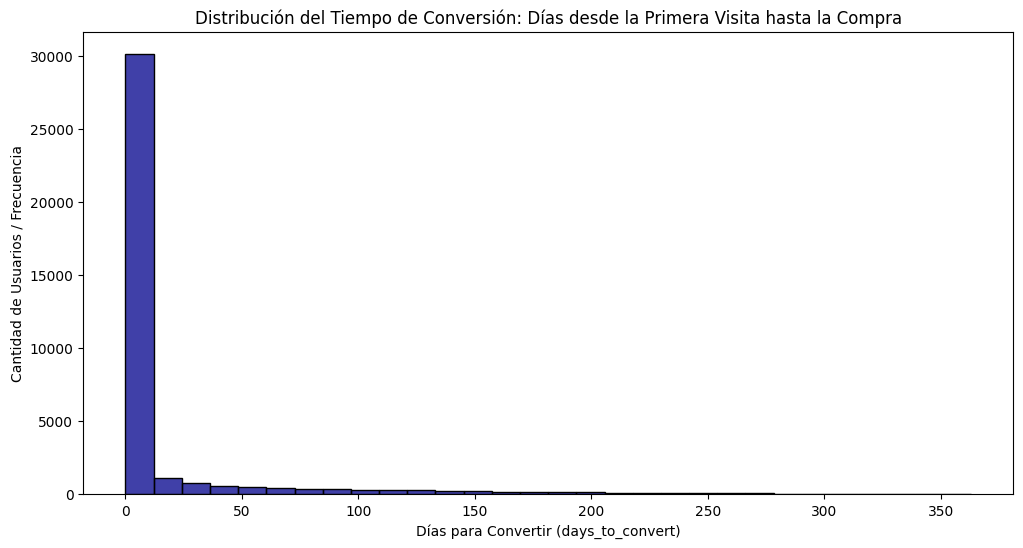

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.histplot(
    data=conversion, 
    x='days_to_convert', 
    bins=30,             
    color='darkblue'      
)
plt.title('Distribución del Tiempo de Conversión: Días desde la Primera Visita hasta la Compra')
plt.xlabel('Días para Convertir (days_to_convert)')
plt.ylabel('Cantidad de Usuarios / Frecuencia')


plt.show()


La mayoría de las compras ocurren casi de inmediato (entre el día 0 y los primeros días tras la primera visita).Si el usuario no compra al momento de conocer el producto o la plataforma, la probabilidad de que lo haga después cae de forma drástica. Tienes un cliente con una ventana de decisión muy corta.
Es más rentable concentrar esfuerzos de campañas la primera semana que durante meses cuando los usuarios ya no compran.

In [22]:
# Contamos cuántos usuarios tardan cada cantidad de días y vemos los 10 casos más comunes
print(conversion['days_to_convert'].value_counts().head(10))
print("Mediana de días para convertir:", conversion['days_to_convert'].median())

0     26363
1      1011
2       563
3       434
4       324
5       270
6       260
7       218
8       189
10      140
Name: days_to_convert, dtype: int64
Mediana de días para convertir: 0.0


In [23]:
#Vamos a extraer el mes para saber cuántos pedidos se realizaron
# 1. Creamos una columna para el mes de la compra
orders['order_month'] = orders['buy_ts'].dt.to_period('M')
# 2. Agrupamos por ese mes y contamos el total de pedidos
pedidos_por_mes = orders.groupby('order_month').agg({'revenue': 'count'}).reset_index()

# 3. Renombramos la columna para que sea clara
pedidos_por_mes.columns = ['order_month', 'total_orders']



print(pedidos_por_mes)

   order_month  total_orders
0      2017-06          2354
1      2017-07          2363
2      2017-08          1807
3      2017-09          3387
4      2017-10          5679
5      2017-11          5659
6      2017-12          6218
7      2018-01          4721
8      2018-02          5281
9      2018-03          5326
10     2018-04          3273
11     2018-05          4346
12     2018-06             1


In [24]:
#Calculamos ahora las ventas promedio por mes

ticket_promedio_mes = orders.groupby('order_month').agg({'revenue': 'mean'}).reset_index()
# Renombramos las columnas 
ticket_promedio_mes.columns = ['order_month', 'ticket_promedio']

print(ticket_promedio_mes)


   order_month  ticket_promedio
0      2017-06         4.060106
1      2017-07         5.306589
2      2017-08         4.847139
3      2017-09         5.416448
4      2017-10         4.928280
5      2017-11         4.783518
6      2017-12         5.852139
7      2018-01         4.112927
8      2018-02         4.840095
9      2018-03         5.413930
10     2018-04         5.150645
11     2018-05         4.771279
12     2018-06         3.420000


In [25]:
#A pesar de que el volumen cambia drásticamente entre meses, el dinero que gasta un usuario en cada compra no varía mucho 
#Esto significa que el crecimiento de los ingresos de la empresa depende del volumen de transacciones, no de lograr que cada cliente gaste fortunas en un solo carrito.

In [26]:
# Extraemos el año y mes de esa primera compra (el mes de la cohorte).

first_order_time=orders.groupby('uid')['buy_ts'].min().reset_index()
first_order_time.columns = ['uid', 'first_order_ts']
first_order_time['first_order_month'] = first_order_time['first_order_ts'].dt.to_period('M')

print(first_order_time.head())


                uid      first_order_ts first_order_month
0   313578113262317 2018-01-03 21:51:00           2018-01
1  1575281904278712 2017-06-03 10:13:00           2017-06
2  2429014661409475 2017-10-11 18:33:00           2017-10
3  2464366381792757 2018-01-28 15:54:00           2018-01
4  2551852515556206 2017-11-24 10:14:00           2017-11


In [27]:
# Unimos la información de la cohorte a todas las compras
orders_merged = pd.merge(orders, first_order_time, on='uid')

# Creamos también la columna del mes en que ocurrió cada compra individual
orders_merged['order_month'] = orders_merged['buy_ts'].dt.to_period('M')

print(orders_merged[['uid', 'first_order_month', 'order_month', 'revenue']].head())



                    uid first_order_month order_month  revenue
0  10329302124590727494           2017-06     2017-06    17.00
1  11627257723692907447           2017-06     2017-06     0.55
2  17903680561304213844           2017-06     2017-06     0.37
3  16109239769442553005           2017-06     2017-06     0.55
4  14200605875248379450           2017-06     2017-06     0.37


In [28]:


# Calculamos la diferencia en meses entre el mes de compra y el mes de la cohorte(creamos nueva columna)
orders_merged['cohort_lifetime'] = (
    (orders_merged['order_month'].dt.year - orders_merged['first_order_month'].dt.year) * 12 +
    (orders_merged['order_month'].dt.month - orders_merged['first_order_month'].dt.month)
)

print(orders_merged[['first_order_month', 'order_month', 'cohort_lifetime', 'revenue']].head())



  first_order_month order_month  cohort_lifetime  revenue
0           2017-06     2017-06                0    17.00
1           2017-06     2017-06                0     0.55
2           2017-06     2017-06                0     0.37
3           2017-06     2017-06                0     0.55
4           2017-06     2017-06                0     0.37


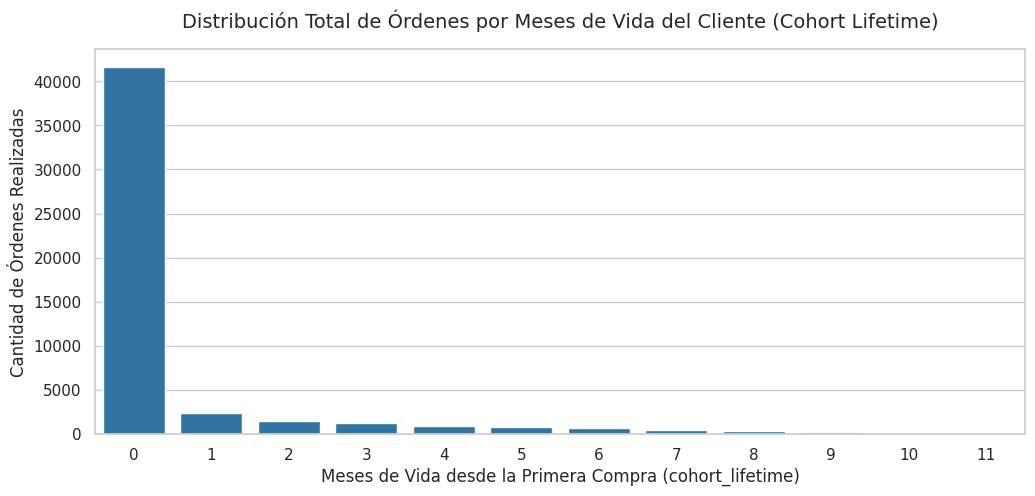

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")

# Contamos el número de órdenes que caen en cada mes de vida
# Usamos un gráfico de barras (countplot) porque 'cohort_lifetime' son números enteros discretos (0, 1, 2, 3...)
sns.countplot(
    data=orders_merged, 
    x='cohort_lifetime', 
    color='#1f77b4'  # Azul clásico para mantener consistencia con tu mapa de calor
)

plt.title('Distribución Total de Órdenes por Meses de Vida del Cliente (Cohort Lifetime)', fontsize=14, pad=15)
plt.xlabel('Meses de Vida desde la Primera Compra (cohort_lifetime)', fontsize=12)
plt.ylabel('Cantidad de Órdenes Realizadas', fontsize=12)

plt.show()

La tasa de abandono es alta después de la primera transacción.Nuevamente los clientes compran una sola vez y a partir del mes 1 se desploma

In [29]:
# Contamos cuántos usuarios únicos tiene cada cohorte para cada mes
cohort_sizes = first_order_time.groupby('first_order_month').agg({'uid': 'nunique'}).reset_index()
cohort_sizes.columns = ['first_order_month', 'n_buyers']

print(cohort_sizes)

   first_order_month  n_buyers
0            2017-06      2023
1            2017-07      1923
2            2017-08      1370
3            2017-09      2581
4            2017-10      4340
5            2017-11      4081
6            2017-12      4383
7            2018-01      3373
8            2018-02      3651
9            2018-03      3533
10           2018-04      2276
11           2018-05      2988
12           2018-06         1


In [30]:

# Agrupamos por el mes de la cohorte y la edad en meses para sumar los ingresos
cohorts_grouped = orders_merged.groupby(['first_order_month', 'cohort_lifetime']).agg({'revenue': 'sum'}).reset_index()

print(cohorts_grouped.head())

  first_order_month  cohort_lifetime  revenue
0           2017-06                0  9557.49
1           2017-06                1   981.82
2           2017-06                2   885.34
3           2017-06                3  1931.30
4           2017-06                4  2068.58


In [31]:
#  Unimos los ingresos agrupados con el tamaño de su respectiva cohorte
report = pd.merge(cohorts_grouped, cohort_sizes, on='first_order_month')

#  Calculamos el ingreso promedio por usuario para ese mes específico
report['gp'] = report['revenue'] / report['n_buyers']

#  Calculamos el LTV acumulado sumando los ingresos mes con mes para cada cohorte
report['ltv'] = report.groupby('first_order_month')['gp'].cumsum()

print(report.head(10))

  first_order_month  cohort_lifetime  revenue  n_buyers        gp        ltv
0           2017-06                0  9557.49      2023  4.724414   4.724414
1           2017-06                1   981.82      2023  0.485329   5.209743
2           2017-06                2   885.34      2023  0.437637   5.647380
3           2017-06                3  1931.30      2023  0.954671   6.602051
4           2017-06                4  2068.58      2023  1.022531   7.624582
5           2017-06                5  1487.92      2023  0.735502   8.360084
6           2017-06                6  1922.74      2023  0.950440   9.310524
7           2017-06                7  1176.56      2023  0.581592   9.892116
8           2017-06                8  1119.15      2023  0.553213  10.445329
9           2017-06                9  1225.51      2023  0.605788  11.051117


In [32]:
# Convertimos el reporte largo en una pivot
ltv_pivot = report.pivot_table(
    index='first_order_month', 
    columns='cohort_lifetime', 
    values='ltv'
)

# Mostramos la tabla redondeada a 2 decimales
print(ltv_pivot.round(2))

cohort_lifetime      0     1     2      3      4      5      6      7      8   \
first_order_month                                                               
2017-06            4.72  5.21  5.65   6.60   7.62   8.36   9.31   9.89  10.45   
2017-07            6.01  6.35  6.97   7.33   7.50   7.66   7.78   7.92   8.08   
2017-08            5.28  5.75  6.21   6.60   7.09   7.38   7.59   7.99   8.28   
2017-09            5.64  6.76  7.28  11.26  11.66  12.31  13.01  13.25  13.44   
2017-10            5.00  5.54  5.73   5.89   6.04   6.16   6.24   6.36    NaN   
2017-11            5.15  5.55  5.75   6.08   6.23   6.28   6.40    NaN    NaN   
2017-12            4.74  5.00  5.92   6.99   7.30   7.64    NaN    NaN    NaN   
2018-01            4.14  4.43  4.73   4.88   4.94    NaN    NaN    NaN    NaN   
2018-02            4.16  4.44  4.51   4.59    NaN    NaN    NaN    NaN    NaN   
2018-03            4.84  5.14  5.46    NaN    NaN    NaN    NaN    NaN    NaN   
2018-04            4.66  5.1

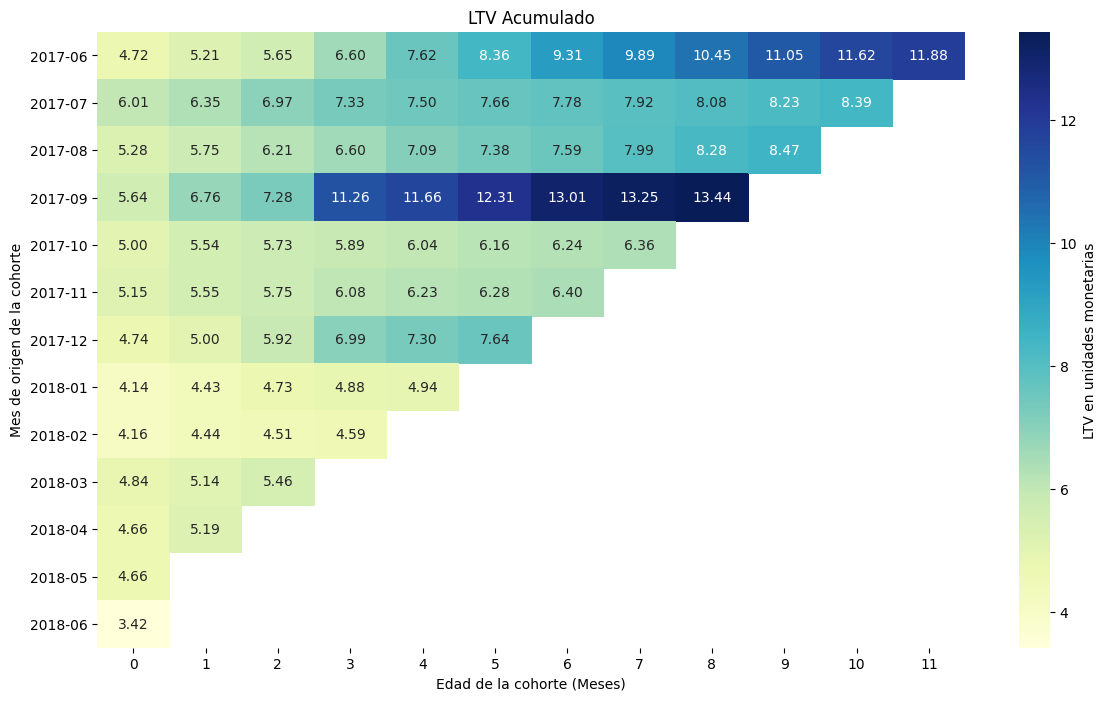

In [33]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
plt.title('LTV Acumulado')

# Creamos el mapa de calor usando Seaborn
sns.heatmap(
    ltv_pivot, 
    annot=True,       # Coloca los números dentro de las celdas
    fmt='.2f',        # Formato con dos decimales
    cmap='YlGnBu',    # Paleta de colores (Amarillo -> Verde -> Azul)
    cbar_kws={'label': 'LTV en unidades monetarias'}
)

plt.xlabel('Edad de la cohorte (Meses)')
plt.ylabel('Mes de origen de la cohorte')
plt.show()

#Los usuarios que se registraron en septiembre tuvieron una retención y un nivel de recompra extraordinarios de cara a las fiestas de fin de año.
Alcanzó un valor de por vida acumulado de 13.44 unidades monetarias gracias a un pico masivo de recompra en su tercer mes de vida (diciembre).

In [35]:
#Analizamos la tabla costs
# Extraemos el año y mes del gasto
costs['month'] = costs['dt'].dt.to_period('M')

print(costs.head())

   source_id         dt  costs    month
0          1 2017-06-01  75.20  2017-06
1          1 2017-06-02  62.25  2017-06
2          1 2017-06-03  36.53  2017-06
3          1 2017-06-04  55.00  2017-06
4          1 2017-06-05  57.08  2017-06


In [36]:
#Calculamos el gasto total y cómo se distribuyó mes con mes

gasto_total = costs['costs'].sum()
print("Gasto Total en Marketing:" ,gasto_total)

# Gasto por Mes (Evolución en el tiempo)
gasto_por_mes = costs.groupby('month').agg({'costs': 'sum'}).reset_index()
print("--- Gasto Mensual ---")
print(gasto_por_mes)

Gasto Total en Marketing: 329131.62
--- Gasto Mensual ---
      month     costs
0   2017-06  18015.00
1   2017-07  18240.59
2   2017-08  14790.54
3   2017-09  24368.91
4   2017-10  36322.88
5   2017-11  37907.88
6   2017-12  38315.35
7   2018-01  33518.52
8   2018-02  32723.03
9   2018-03  30415.27
10  2018-04  22289.38
11  2018-05  22224.27


In [37]:
# Gasto por canal de marketing
gasto_por_fuente = costs.groupby('source_id').agg({'costs': 'sum'}).reset_index().sort_values(by='costs', ascending=False)
print("--- Gasto por Plataforma ---")
print(gasto_por_fuente)

--- Gasto por Plataforma ---
   source_id      costs
2          3  141321.63
3          4   61073.60
4          5   51757.10
1          2   42806.04
0          1   20833.27
6         10    5822.49
5          9    5517.49


In [38]:
#Ahora vamos a calcular el Costo de Adqusición de Clientes (CAC)
# Aseguramos que la columna 'month' de gasto_por_mes sea de tipo periodo para poder unirla
gasto_por_mes['month'] = gasto_por_mes['month'].astype(str)
cohort_sizes['first_order_month'] = cohort_sizes['first_order_month'].astype(str)

# Unimos el gasto mensual con el tamaño de las cohortes de compradores nuevos
cac_report = pd.merge(gasto_por_mes, cohort_sizes, left_on='month', right_on='first_order_month')

# Calculamos el CAC dividiendo el costo entre el número de compradores nuevos
cac_report['cac'] = cac_report['costs'] / cac_report['n_buyers']

print(cac_report[['month', 'costs', 'n_buyers', 'cac']].round(2))

      month     costs  n_buyers    cac
0   2017-06  18015.00      2023   8.91
1   2017-07  18240.59      1923   9.49
2   2017-08  14790.54      1370  10.80
3   2017-09  24368.91      2581   9.44
4   2017-10  36322.88      4340   8.37
5   2017-11  37907.88      4081   9.29
6   2017-12  38315.35      4383   8.74
7   2018-01  33518.52      3373   9.94
8   2018-02  32723.03      3651   8.96
9   2018-03  30415.27      3533   8.61
10  2018-04  22289.38      2276   9.79
11  2018-05  22224.27      2988   7.44


In [39]:
#Ahora vamos a calcular el ROI ¿Las inversiones en Marketing fueron rentables?

#  Aseguramos que el índice de ltv_pivot sea texto ('string')
ltv_pivot.index = ltv_pivot.index.astype(str)

# Aseguramos que el diccionario de CAC también tenga sus claves como texto
cac_report['month'] = cac_report['month'].astype(str)
cac_dict = cac_report.set_index('month')['cac']

# Hacemos la división 
romi_pivot = ltv_pivot.div(cac_dict, axis=0)


# Mostramos la matriz final de rentabilidad
print(romi_pivot.round(2))

cohort_lifetime    0     1     2     3     4     5     6     7     8     9   \
2017-06          0.53  0.59  0.63  0.74  0.86  0.94  1.05  1.11  1.17  1.24   
2017-07          0.63  0.67  0.73  0.77  0.79  0.81  0.82  0.84  0.85  0.87   
2017-08          0.49  0.53  0.57  0.61  0.66  0.68  0.70  0.74  0.77  0.78   
2017-09          0.60  0.72  0.77  1.19  1.23  1.30  1.38  1.40  1.42   NaN   
2017-10          0.60  0.66  0.68  0.70  0.72  0.74  0.75  0.76   NaN   NaN   
2017-11          0.55  0.60  0.62  0.65  0.67  0.68  0.69   NaN   NaN   NaN   
2017-12          0.54  0.57  0.68  0.80  0.84  0.87   NaN   NaN   NaN   NaN   
2018-01          0.42  0.45  0.48  0.49  0.50   NaN   NaN   NaN   NaN   NaN   
2018-02          0.46  0.49  0.50  0.51   NaN   NaN   NaN   NaN   NaN   NaN   
2018-03          0.56  0.60  0.63   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2018-04          0.48  0.53   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2018-05          0.63   NaN   NaN   NaN   NaN   NaN 

#Conclusión final
Rentabilidad a largo plazo: El negocio demuestra la capacidad de recuperar la inversión en marketing, pero depende enteramente de la retención de los usuarios a mediano plazo, ya que ninguna cohorte es rentable en su primer mes (Día 0).
Casos de Éxito y Fracaso: Cabe destacar la cohorte de septiembre de 2017, la cual fue la más rápida en volverse rentable (al mes 3 con un ROMI de 1.19) y la más lucrativa (ROMI acumulado de 1.42). 
#Por el contrario, las cohortes de julio y agosto de 2017 representan una pérdida para el negocio al no alcanzar el punto de equilibrio (1.0) tras casi un año de seguimiento, penalizadas principalmente por un costo de adquisición (CAC) elevado.
#Recomendación Estratégica: Se sugiere auditar y replicar las campañas implementadas en septiembre de 2017 para replicar su estrategia de retención.